In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# ── Notebook display settings ─────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8')

# ── Database connection ───────────────────────
DB_PATH = r"C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\supply_chain.db"
conn = sqlite3.connect(DB_PATH)
print("Connected to supply_chain.db")
print("Ready to analyse 1.5M+ rows of supply chain data")

Connected to supply_chain.db
Ready to analyse 1.5M+ rows of supply chain data


In [2]:
# Load all tables from SQLite into pandas DataFrames
orders    = pd.read_sql("SELECT * FROM orders", conn)
customers = pd.read_sql("SELECT * FROM customers", conn)
items     = pd.read_sql("SELECT * FROM order_items", conn)
reviews   = pd.read_sql("SELECT * FROM reviews", conn)
shipments = pd.read_sql("SELECT * FROM shipments", conn)

# Load our star schema fact table
fact = pd.read_sql("""
    SELECT
        f.*,
        c.customer_state,
        c.customer_city
    FROM fact_shipments f
    LEFT JOIN customers c ON f.customer_id = c.customer_id
    WHERE f.is_delivered = 1
""", conn)

print("DataFrames loaded:")
print(f"  orders    : {orders.shape}")
print(f"  customers : {customers.shape}")
print(f"  items     : {items.shape}")
print(f"  reviews   : {reviews.shape}")
print(f"  shipments : {shipments.shape}")
print(f"  fact      : {fact.shape} (delivered orders with geography)")

DataFrames loaded:
  orders    : (99441, 8)
  customers : (99441, 5)
  items     : (112650, 7)
  reviews   : (99224, 7)
  shipments : (10999, 12)
  fact      : (110197, 16) (delivered orders with geography)


In [3]:
# ── Data health check ────────────────────────
print("=" * 50)
print("FACT TABLE HEALTH CHECK")
print("=" * 50)
print(f"\nShape: {fact.shape}")
print(f"\nColumn names:\n{list(fact.columns)}")
print(f"\nMissing values:")
print(fact.isnull().sum()[fact.isnull().sum() > 0])
print(f"\nData types:")
print(fact.dtypes)
print(f"\nSample data:")
fact.head(3)

FACT TABLE HEALTH CHECK

Shape: (110197, 16)

Column names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_estimated_delivery_date', 'order_delivered_customer_date', 'freight_value', 'price', 'product_id', 'seller_id', 'actual_delivery_days', 'delay_vs_estimate', 'is_on_time', 'is_delivered', 'customer_state', 'customer_city']

Missing values:
order_delivered_customer_date    8
actual_delivery_days             8
delay_vs_estimate                8
dtype: int64

Data types:
order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_estimated_delivery_date        str
order_delivered_customer_date        str
freight_value                    float64
price                            float64
product_id                           str
seller_id                            str
actual_delivery_days             float64
delay_vs_estimate                float64

,order_id,customer_id,order_status,order_purchase_timestamp,order_estimated_delivery_date,order_delivered_customer_date,freight_value,price,product_id,seller_id,actual_delivery_days,delay_vs_estimate,is_on_time,is_delivered,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-18 00:00:00,2017-10-10 21:25:13,8.72,29.99,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,8.40,-7.10,1,1,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-08-13 00:00:00,2018-08-07 15:27:45,22.76,118.70,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,13.80,-5.40,0,1,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-09-04 00:00:00,2018-08-17 18:06:29,19.22,159.90,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,9.40,-17.20,1,1,GO,vianopolis


In [4]:
# ── Convert date columns from text to datetime ─
date_cols = [
    'order_purchase_timestamp',
    'order_estimated_delivery_date',
    'order_delivered_customer_date'
]
for col in date_cols:
    fact[col] = pd.to_datetime(fact[col])

# ── Create analysis columns ────────────────────
# Extract month and year for trend analysis
fact['purchase_month'] = fact['order_purchase_timestamp'].dt.to_period('M')
fact['purchase_year']  = fact['order_purchase_timestamp'].dt.year
fact['purchase_dow']   = fact['order_purchase_timestamp'].dt.day_name()

# Create price tier column
fact['price_tier'] = pd.cut(
    fact['price'],
    bins=[0, 50, 200, 99999],
    labels=['Budget', 'Mid-range', 'Premium']
)

# Create delivery speed category
fact['delivery_speed'] = pd.cut(
    fact['actual_delivery_days'],
    bins=[0, 7, 12, 20, 30, 999],
    labels=['Fast','On-time','Slow','Very slow','Critical']
)

print("Date columns converted successfully")
print(f"\nNew columns added: purchase_month, purchase_year,")
print(f"purchase_dow, price_tier, delivery_speed")
print(f"\nPrice tier distribution:")
print(fact['price_tier'].value_counts())

Date columns converted successfully

New columns added: purchase_month, purchase_year,
purchase_dow, price_tier, delivery_speed

Price tier distribution:
price_tier
Mid-range    58732
Budget       38530
Premium      12935
Name: count, dtype: int64


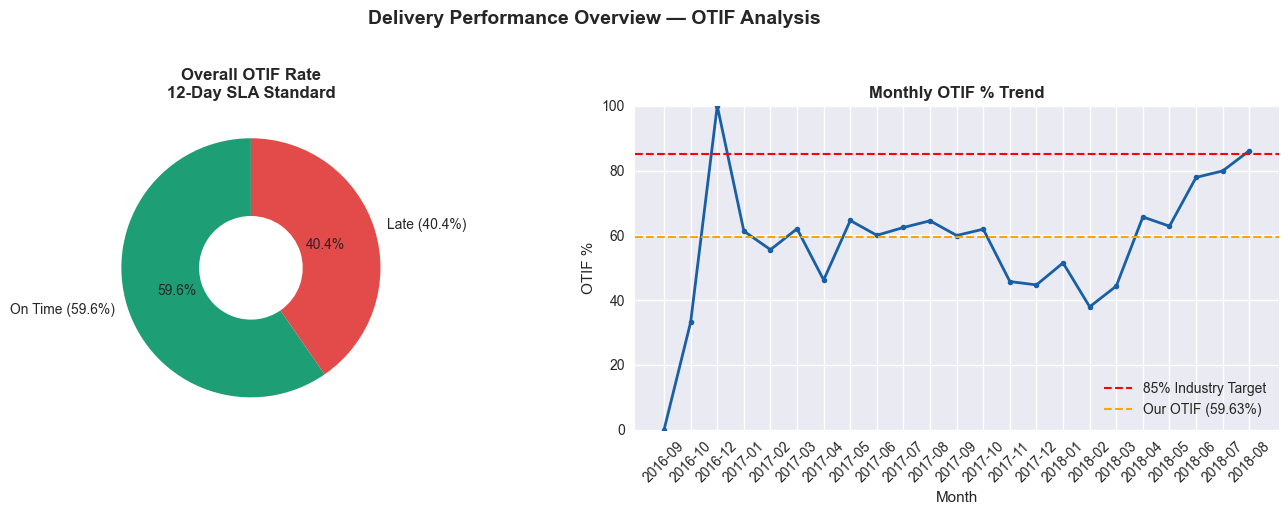

Chart 1 saved to data/processed/


In [5]:
# ── Chart 1: OTIF Summary ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Delivery Performance Overview — OTIF Analysis',
             fontsize=14, fontweight='bold', y=1.02)

# Left: OTIF donut chart
otif_counts = fact['is_on_time'].value_counts()
colors = ['#1D9E75', '#E24B4A']
axes[0].pie(
    otif_counts,
    labels=['On Time (59.6%)', 'Late (40.4%)'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.6}  # makes it a donut
)
axes[0].set_title('Overall OTIF Rate\n12-Day SLA Standard',
                  fontsize=12, fontweight='bold')

# Right: Monthly OTIF trend
monthly_otif = (fact.groupby('purchase_month')['is_on_time']
                .mean()
                .mul(100)
                .reset_index())
monthly_otif.columns = ['month', 'otif_pct']
monthly_otif['month_str'] = monthly_otif['month'].astype(str)

axes[1].plot(monthly_otif['month_str'],
             monthly_otif['otif_pct'],
             color='#185FA5', linewidth=2, marker='o', markersize=4)
axes[1].axhline(y=85, color='red', linestyle='--',
                linewidth=1.5, label='85% Industry Target')
axes[1].axhline(y=59.63, color='orange', linestyle='--',
                linewidth=1.5, label='Our OTIF (59.63%)')
axes[1].set_title('Monthly OTIF % Trend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('OTIF %')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(r'C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed\chart1_otif_overview.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved to data/processed/")

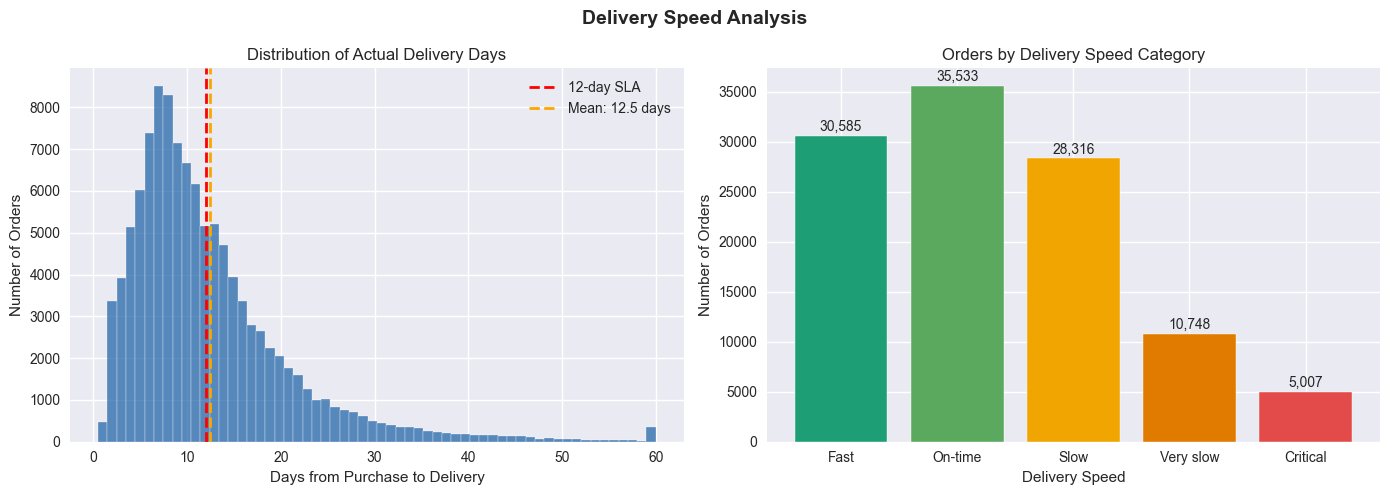

In [6]:
# ── Chart 2: Delivery speed distribution ──────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Delivery Speed Analysis', fontsize=14, fontweight='bold')

# Left: Histogram of actual delivery days
delivered = fact[fact['actual_delivery_days'].notna()].copy()
axes[0].hist(
    delivered['actual_delivery_days'].clip(0, 60),
    bins=60,
    color='#185FA5',
    alpha=0.7,
    edgecolor='white'
)
axes[0].axvline(x=12, color='red', linestyle='--',
                linewidth=2, label='12-day SLA')
axes[0].axvline(x=delivered['actual_delivery_days'].mean(),
                color='orange', linestyle='--',
                linewidth=2, label=f'Mean: {delivered["actual_delivery_days"].mean():.1f} days')
axes[0].set_title('Distribution of Actual Delivery Days')
axes[0].set_xlabel('Days from Purchase to Delivery')
axes[0].set_ylabel('Number of Orders')
axes[0].legend()

# Right: Delivery speed category breakdown
speed_counts = fact['delivery_speed'].value_counts().sort_index()
colors_speed = ['#1D9E75','#5BA85F','#F0A500','#E07B00','#E24B4A']
bars = axes[1].bar(speed_counts.index, speed_counts.values,
                   color=colors_speed, edgecolor='white')
axes[1].set_title('Orders by Delivery Speed Category')
axes[1].set_xlabel('Delivery Speed')
axes[1].set_ylabel('Number of Orders')
# Add value labels on top of each bar
for bar, val in zip(bars, speed_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{val:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(r'C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed\chart2_delivery_speed.png',
            dpi=150, bbox_inches='tight')
plt.show()

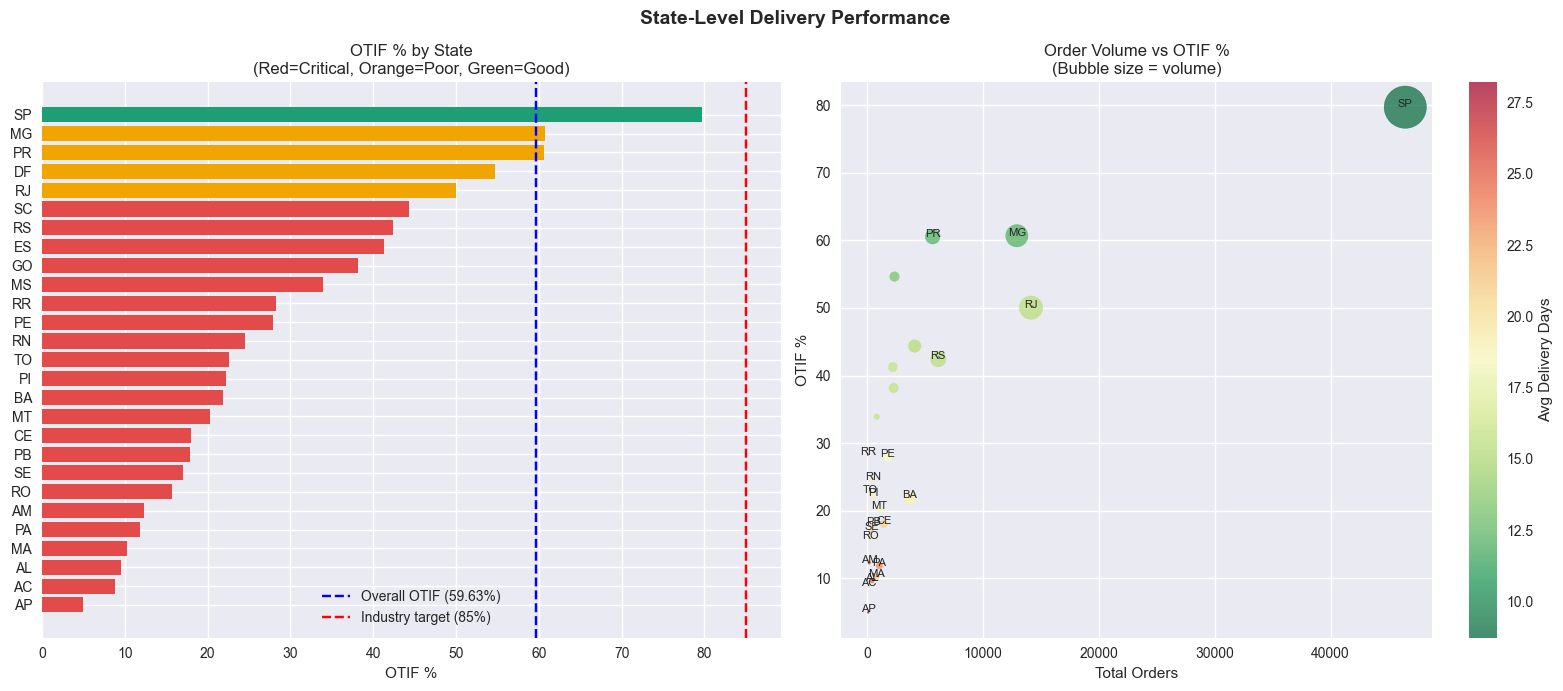

In [7]:
# ── Chart 3: State performance analysis ────────
state_perf = (fact.groupby('customer_state')
              .agg(
                  total_orders=('order_id', 'count'),
                  otif_pct=('is_on_time', lambda x: round(x.mean()*100, 2)),
                  avg_delivery_days=('actual_delivery_days', 'mean')
              )
              .reset_index()
              .sort_values('otif_pct', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('State-Level Delivery Performance', fontsize=14, fontweight='bold')

# Left: OTIF by state (horizontal bar)
colors_bar = ['#E24B4A' if x < 50 else '#F0A500' if x < 65
              else '#1D9E75' for x in state_perf['otif_pct']]
axes[0].barh(state_perf['customer_state'],
             state_perf['otif_pct'],
             color=colors_bar)
axes[0].axvline(x=59.63, color='blue', linestyle='--',
                label='Overall OTIF (59.63%)')
axes[0].axvline(x=85, color='red', linestyle='--',
                label='Industry target (85%)')
axes[0].set_title('OTIF % by State\n(Red=Critical, Orange=Poor, Green=Good)')
axes[0].set_xlabel('OTIF %')
axes[0].legend()

# Right: Scatter — order volume vs OTIF
scatter = axes[1].scatter(
    state_perf['total_orders'],
    state_perf['otif_pct'],
    s=state_perf['total_orders']/50,  # bubble size = volume
    c=state_perf['avg_delivery_days'],
    cmap='RdYlGn_r',
    alpha=0.7
)
# Label key states
for _, row in state_perf.iterrows():
    if row['total_orders'] > 5000 or row['otif_pct'] < 30:
        axes[1].annotate(row['customer_state'],
                         (row['total_orders'], row['otif_pct']),
                         fontsize=8, ha='center')
plt.colorbar(scatter, ax=axes[1], label='Avg Delivery Days')
axes[1].set_title('Order Volume vs OTIF %\n(Bubble size = volume)')
axes[1].set_xlabel('Total Orders')
axes[1].set_ylabel('OTIF %')

plt.tight_layout()
plt.savefig(r'C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed\chart3_state_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()

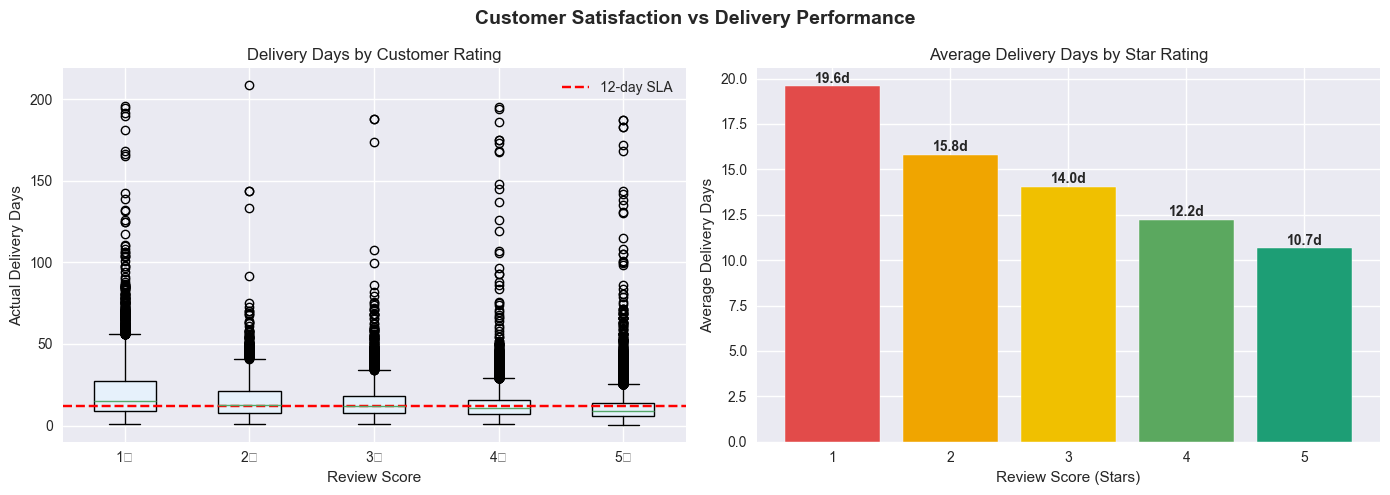

In [8]:
# ── Load reviews and merge ────────────────────
reviews_df = pd.read_sql("SELECT * FROM reviews", conn)
fact_reviews = fact.merge(
    reviews_df[['order_id', 'review_score']],
    on='order_id',
    how='left'
)
fact_reviews = fact_reviews.dropna(subset=['review_score'])

# ── Chart 4: Review score vs delivery days ────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Customer Satisfaction vs Delivery Performance',
             fontsize=14, fontweight='bold')

# Left: Box plot — delivery days by review score
review_groups = [
    fact_reviews[fact_reviews['review_score']==score]['actual_delivery_days'].dropna()
    for score in [1, 2, 3, 4, 5]
]
axes[0].boxplot(review_groups, labels=['1★','2★','3★','4★','5★'],
                patch_artist=True,
                boxprops=dict(facecolor='#E6F1FB'))
axes[0].axhline(y=12, color='red', linestyle='--', label='12-day SLA')
axes[0].set_title('Delivery Days by Customer Rating')
axes[0].set_xlabel('Review Score')
axes[0].set_ylabel('Actual Delivery Days')
axes[0].legend()

# Right: Average delivery days per star rating
avg_by_score = (fact_reviews.groupby('review_score')
                ['actual_delivery_days'].mean())
colors_review = ['#E24B4A','#F0A500','#F0C000','#5BA85F','#1D9E75']
axes[1].bar(avg_by_score.index, avg_by_score.values,
            color=colors_review, edgecolor='white')
axes[1].set_title('Average Delivery Days by Star Rating')
axes[1].set_xlabel('Review Score (Stars)')
axes[1].set_ylabel('Average Delivery Days')
for i, (score, val) in enumerate(avg_by_score.items()):
    axes[1].text(score, val+0.2, f'{val:.1f}d',
                 ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(r'C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed\chart4_satisfaction_delivery.png',
            dpi=150, bbox_inches='tight')
plt.show()

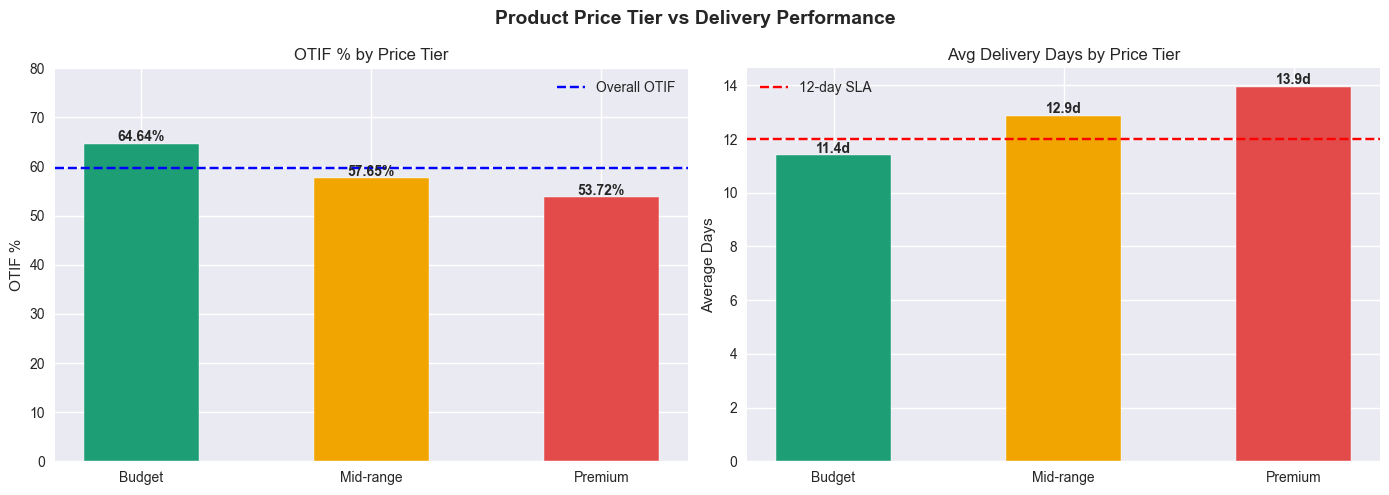


KEY FINDING:
price_tier  otif_pct  avg_days
    Budget     64.64     11.39
 Mid-range     57.65     12.86
   Premium     53.72     13.94


In [9]:
# ── Chart 5: Price tier analysis ──────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Product Price Tier vs Delivery Performance',
             fontsize=14, fontweight='bold')

tier_perf = (fact.groupby('price_tier', observed=True)
             .agg(
                 order_count=('order_id', 'count'),
                 otif_pct=('is_on_time', lambda x: round(x.mean()*100,2)),
                 avg_days=('actual_delivery_days', 'mean'),
                 avg_price=('price', 'mean')
             ).reset_index())

# Left: OTIF by price tier
colors_tier = ['#1D9E75','#F0A500','#E24B4A']
bars = axes[0].bar(tier_perf['price_tier'],
                   tier_perf['otif_pct'],
                   color=colors_tier, edgecolor='white', width=0.5)
axes[0].axhline(y=59.63, color='blue', linestyle='--',
                label='Overall OTIF')
for bar, val in zip(bars, tier_perf['otif_pct']):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.5,
                 f'{val}%', ha='center', fontweight='bold')
axes[0].set_title('OTIF % by Price Tier')
axes[0].set_ylabel('OTIF %')
axes[0].set_ylim(0, 80)
axes[0].legend()

# Right: Average delivery days by tier
axes[1].bar(tier_perf['price_tier'],
            tier_perf['avg_days'],
            color=colors_tier, edgecolor='white', width=0.5)
axes[1].axhline(y=12, color='red', linestyle='--', label='12-day SLA')
for i, (_, row) in enumerate(tier_perf.iterrows()):
    axes[1].text(i, row['avg_days']+0.1,
                 f'{row["avg_days"]:.1f}d',
                 ha='center', fontweight='bold')
axes[1].set_title('Avg Delivery Days by Price Tier')
axes[1].set_ylabel('Average Days')
axes[1].legend()

plt.tight_layout()
plt.savefig(r'C:\Users\ASUS ROG\last-mile-delivery-intelligence\data\processed\chart5_price_tier.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print key finding
print("\nKEY FINDING:")
print(tier_perf[['price_tier','otif_pct','avg_days']].to_string(index=False))